# Retail Sales Trend and Seasonality Analysis

### Load the python libraries required for data hadling and vizualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


### Read the input file

In [3]:
#The dataset is taken form kaggle
df=pd.read_csv(r"C:\Users\jayas\Downloads\archive (1)\Sales Dataset.csv") 

#### Check what are the columns present in out dataset

In [4]:
df.head()

,Unnamed: 0,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,0,2023-11-24,Male,34,Beauty,3,50,150
1,1,2023-02-27,Female,26,Clothing,2,500,1000
2,2,2023-01-13,Male,50,Electronics,1,30,30
3,3,2023-05-21,Male,37,Clothing,1,500,500
4,4,2023-05-06,Male,30,Beauty,2,50,100


#### Drop the unwanted columns

In [5]:
df.drop(columns=['Unnamed: 0'], inplace=True)

##### Convert the Date column into  proper date time format

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

We Only need the data and the total amount of sales that happened over that particular day.So we are using the group by function 
take them separately

In [7]:
daily_sales = df.groupby('Date')['Total Amount'].sum()

In [15]:
daily_sales.head()

Date
2023-01-01    3600.0
2023-01-02    1765.0
2023-01-03     600.0
2023-01-04    1240.0
2023-01-05    1100.0
Freq: D, Name: Total Amount, dtype: float64

We sort the index to make sure the data is in correct date order, because time-series analysis must follow the flow of time. Then we use asfreq('D') to make the data strictly daily, so that every day appears in the dataset. If any days are missing, they are added with empty values. This helps in finding missing days, calculating trends, rolling averages, and building forecasting models, which all require data at regular time intervals.

In [8]:
daily_sales = daily_sales.sort_index()
daily_sales = daily_sales.asfreq('D')

In [16]:
#Remove the null values
daily_sales = daily_sales.fillna(0)

## Daily Retail sales Over Time
Sudden spikes indicate days with unusually high sales (such as festivals or promotions), while drops or flat lines may indicate low-demand days or missing sales.

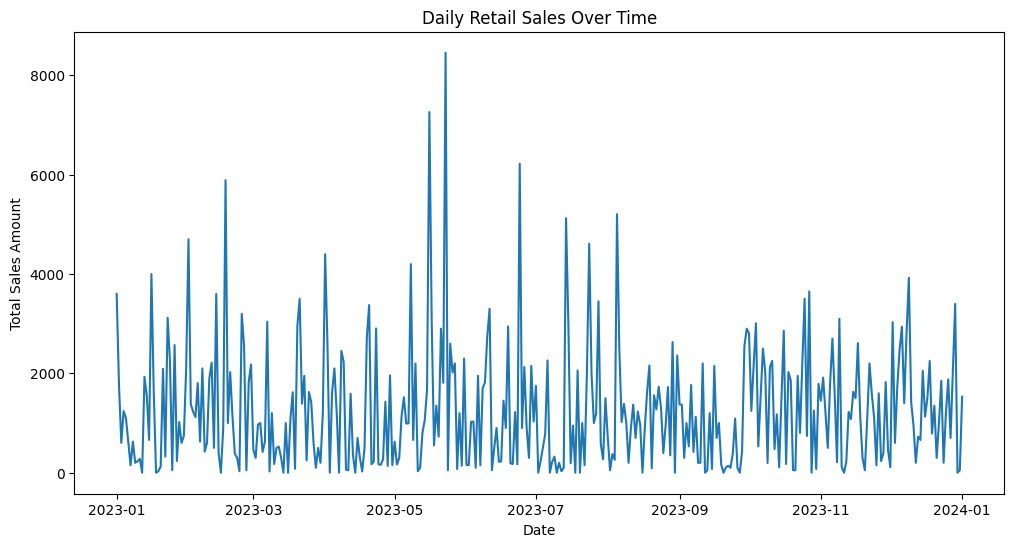

In [10]:
plt.figure(figsize=(12,6))
plt.plot(daily_sales)
plt.title("Daily Retail Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales Amount")
plt.show()

This code performs time-series decomposition on daily sales data to break it into three meaningful components: trend, seasonality, and residual noise. The seasonal_decompose function is used with an additive model, which assumes that the observed sales are the sum of trend, seasonal pattern, and random noise. The period=30 indicates a 30-day repeating cycle, such as a monthly pattern. The trend plot shows the long-term movement in sales over time, the seasonal plot highlights repeating patterns within each 30-day period, and the residual plot displays random fluctuations that are not explained by trend or seasonality. Together, these plots help us understand underlying patterns and irregular behavior in daily sales data.

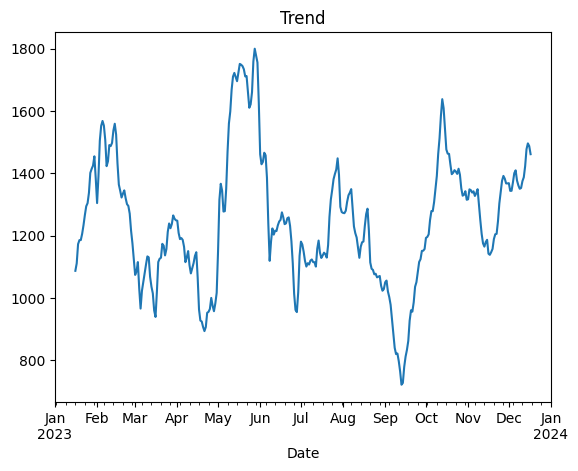

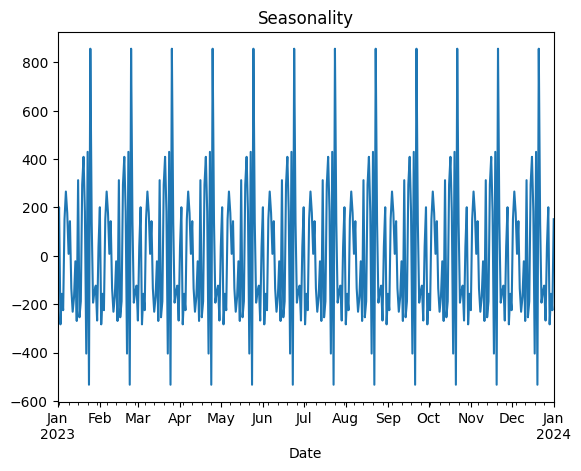

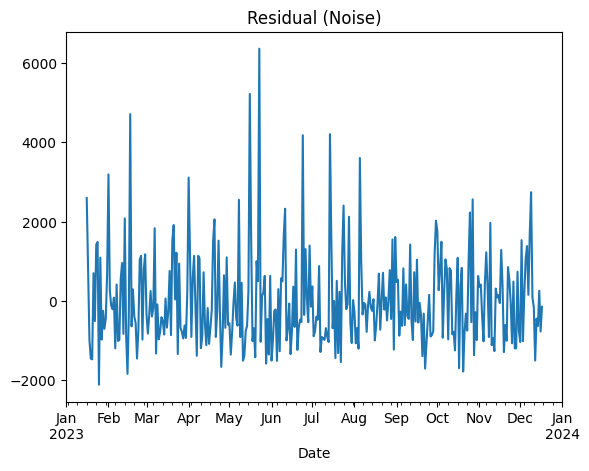

In [11]:
decomposition = seasonal_decompose(daily_sales, model='additive', period=30)

decomposition.trend.plot(title='Trend')
plt.show()

decomposition.seasonal.plot(title='Seasonality')
plt.show()

decomposition.resid.plot(title='Residual (Noise)')
plt.show()


This code plots the ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) of the daily sales data to understand how current sales are related to past sales values. The ACF plot shows the correlation between today’s sales and sales from previous days (lags) up to 30 days, helping identify repeating patterns or seasonality. The PACF plot shows the direct influence of a specific past day on today’s sales, removing the effect of intermediate days. These plots are mainly used to decide appropriate parameters for time-series forecasting models like ARIMA.

<Figure size 1000x400 with 0 Axes>

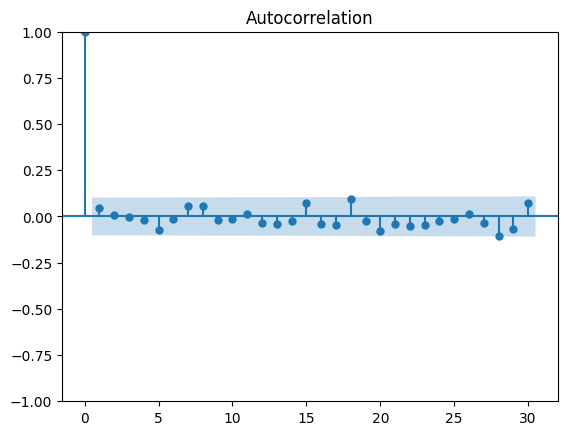

<Figure size 1000x400 with 0 Axes>

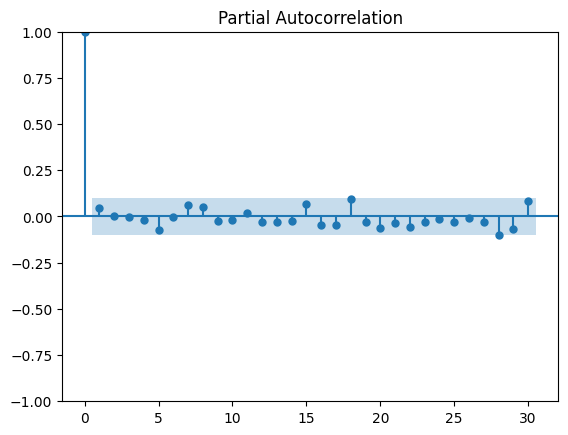

In [12]:
plt.figure(figsize=(10,4))
plot_acf(daily_sales, lags=30)
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(daily_sales, lags=30)
plt.show()


This code applies the Augmented Dickey–Fuller (ADF) test to the daily sales data to check whether the time series is stationary or not. The ADF statistic measures how strongly the data shows a unit root (non-stationarity), and the p-value helps us make the decision. If the p-value is less than 0.05, the sales data is considered stationary, meaning its mean and variance do not change over time. If the p-value is greater than 0.05, the data is non-stationary and may need transformations like differencing before forecasting.

In [17]:
adf_result = adfuller(daily_sales)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


ADF Statistic: -18.311223980299374
p-value: 2.2758745115369364e-30


This code calculates the 30-day rolling mean and rolling standard deviation of daily sales and plots them along with the original sales data. The rolling mean shows the average sales over the last 30 days, helping smooth short-term fluctuations and highlight the overall trend. The rolling standard deviation shows how much sales vary within the same 30-day window, indicating changes in volatility. By comparing these with the original data, we can visually check whether the mean and variance remain constant over time, which helps in assessing whether the time series is stationary.

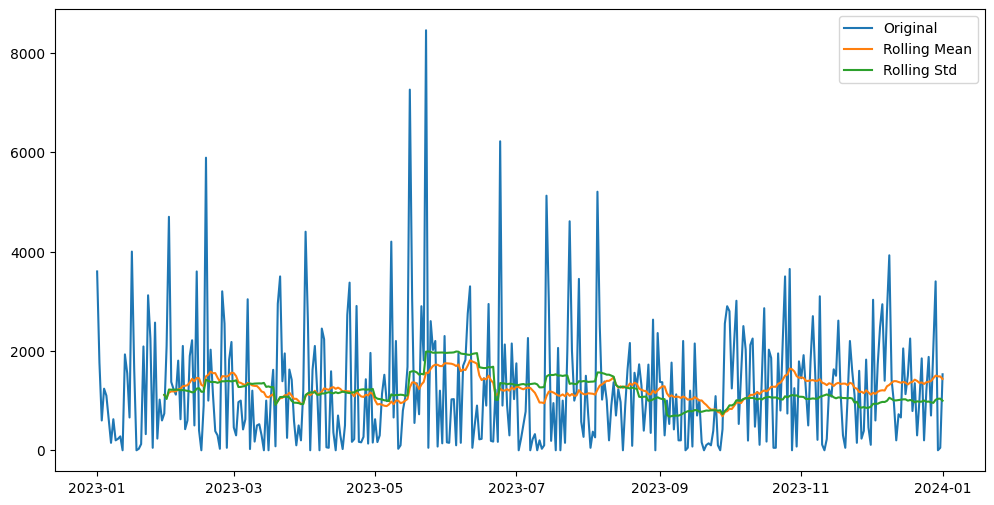

In [14]:
rolling_mean = daily_sales.rolling(window=30).mean()
rolling_std = daily_sales.rolling(window=30).std()

plt.figure(figsize=(12,6))
plt.plot(daily_sales, label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.show()
